In [1]:
import pandas as pd
import numpy as np
from lstnn.parcellation import Parcellation
import matplotlib.pyplot as plt
import seaborn as sns

# parameters
pe_desc = "2dpe"
fmethod = "crossnobis" # "crossnobis"
amethod = "euclidean" #  "euclidean"
cmethod = "corr" 
epoch = 4000
n_perms = 10000
atlas = "Glasser"

if atlas == "Glasser":
    cortex = 'Glasser'
    cortex_res = None
    scale = 1
elif atlas == "Schaefer":
    cortex = 'Schaefer'
    cortex_res = 400
    scale = 1

parc = Parcellation(cortex=cortex, cortex_res=cortex_res, scale=scale)

df_list = []
in_file = f"/home/lukeh/projects/LSTNN/results/model_comparison/group_atlas-{atlas}/pe-{pe_desc}"
in_file += f"_fmethod-{fmethod}_amethod-{amethod}_cmethod-{cmethod}"
in_file += f"_epoch-{epoch}_nperms-{n_perms}"

#df_all = pd.read_csv(in_file+".csv")
df = pd.read_csv(in_file+"_stats.csv")
df.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
0,0.015285,False,corr,pe_layer0,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7336,NaN
1,0.029015,False,corr,pe_layer1,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.8654,NaN
2,-0.005313,False,corr,pe_layer2,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.4318,NaN
3,0.014045,False,corr,pe_layer3,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.7065,NaN
4,0.015040,False,corr,pe_avg,HIP-rh,0,2dpe,crossnobis,corr,euclidean,4000,1.0,0.6997,NaN


In [2]:
data = df.loc[((df.model == "pe_avg") | (df.model == "attn_out_avg") | df.model.str.startswith("mlp_layer"))
              & (df.p_FDR < 0.05)]
data.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
244,0.262385,False,corr,pe_avg,R_V1_ROI,0,2dpe,crossnobis,corr,euclidean,4000,0.000000,1.0000,Visual1
250,0.150882,False,corr,mlp_layer0,R_V1_ROI,0,2dpe,crossnobis,corr,euclidean,4000,0.000000,1.0000,Visual1
251,0.275939,False,corr,mlp_layer1,R_V1_ROI,0,2dpe,crossnobis,corr,euclidean,4000,0.000000,1.0000,Visual1
252,0.165484,False,corr,mlp_layer2,R_V1_ROI,0,2dpe,crossnobis,corr,euclidean,4000,0.011082,0.9999,Visual1
289,0.167042,False,corr,pe_avg,R_V2_ROI,0,2dpe,crossnobis,corr,euclidean,4000,0.000000,1.0000,Visual2


## Loading noise ceilings

In [3]:
nc_perms = 1000
noise_ceilings = []

# functions
def spearmanbrown(rho, k):
  """adjust the correlation coefficient r for test length by scaling by k, which
  defines the full length (e.g., if the full length is twice of what r was 
  calculated for, k=2)."""
  # SB is undefined if r<0
  thisr = rho * np.array(rho > 0., dtype='float')
  thisr = (k * thisr) / (1 + (k - 1) * thisr)
  return thisr


def summary_stats(x):
    """Return mean, 5th percentile, and 95th percentile of an array."""
    x = np.asarray(x)
    return np.mean(x), np.percentile(x, 5), np.percentile(x, 95)


# load relevant noise ceilings
for roi in parc.parcel_labels:
    fname = (
        f"/home/lukeh/projects/LSTNN/results/noise_ceilings/group_"
        f"atlas-{atlas}/fmethod-{fmethod}_"
        f"cmethod-spearman_"
        f"nperms-{nc_perms}_roi-{roi}.csv"
    )
    df = pd.read_csv(fname)
    value, bottom, top = summary_stats(df.rho.values)

    nc = pd.DataFrame()
    nc["stat"] = [value]
    nc["permutation"] = "noise ceiling"
    nc["parcel"] = roi
    noise_ceilings.append(nc)

    nc = pd.DataFrame()
    nc["stat"] = [spearmanbrown(value, k=2)]
    nc["permutation"] = "noise ceiling corr."
    nc["parcel"] = roi
    noise_ceilings.append(nc)

    nc = pd.DataFrame()
    nc["stat"] = [spearmanbrown(bottom, k=2)]
    nc["permutation"] = "noise ceiling corr. bottom"
    nc["parcel"] = roi
    noise_ceilings.append(nc)


    nc = pd.DataFrame()
    nc["stat"] = [spearmanbrown(top, k=2)]
    nc["permutation"] = "noise ceiling corr. top"
    nc["parcel"] = roi
    noise_ceilings.append(nc)


noise_ceilings = pd.concat(noise_ceilings)
noise_ceilings.head()

,stat,permutation,parcel
0,0.272106,noise ceiling,HIP-rh
0,0.427804,noise ceiling corr.,HIP-rh
0,0.316101,noise ceiling corr. bottom,HIP-rh
0,0.517323,noise ceiling corr. top,HIP-rh
0,0.419859,noise ceiling,AMY-rh


In [4]:
noise_ceilings.sort_values(by='stat', ascending=True)

,stat,permutation,parcel
0,-0.036771,noise ceiling,L_47s_ROI
0,-0.033456,noise ceiling,R_TF_ROI
0,-0.033426,noise ceiling,L_STSvp_ROI
0,-0.032106,noise ceiling,R_TPOJ2_ROI
0,-0.030888,noise ceiling,L_45_ROI
...,...,...,...
0,0.875143,noise ceiling corr. top,L_7PL_ROI
0,0.875450,noise ceiling corr. top,L_6a_ROI
0,0.880785,noise ceiling corr. top,R_7PL_ROI
0,0.881207,noise ceiling corr. top,L_VIP_ROI


In [5]:
noise_ceilings.loc[noise_ceilings.parcel == "R_MST_ROI"]

,stat,permutation,parcel
0,-0.028395,noise ceiling,R_MST_ROI
0,-0.000000,noise ceiling corr.,R_MST_ROI
0,-0.000000,noise ceiling corr. bottom,R_MST_ROI
0,0.057709,noise ceiling corr. top,R_MST_ROI


pixdim[1,2,3] should be non-zero; setting 0 dims to 1


0.8556700819995652
0.8 -0.8


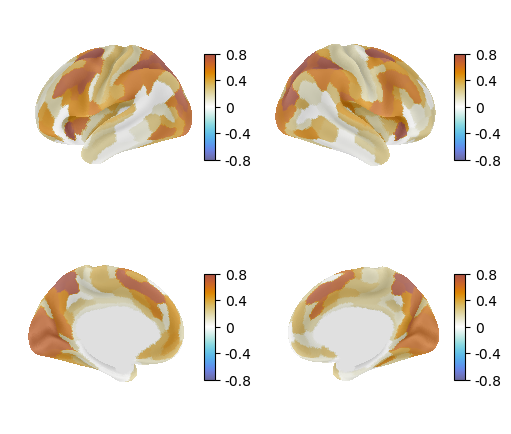

In [6]:
from lstnn.plotting import pub_surf_plot
import cmasher as cmr

#cmap = cmr.sunburst
cmap = cmr.prinsenvlag_r
plot_data = noise_ceilings.loc[noise_ceilings.permutation == "noise ceiling corr.", "stat"].values
print(np.max(plot_data))
vmax=0.8
vmin = vmax*-1
print(vmax, vmin)
pub_surf_plot(plot_data, parc.file, save=None, size=(5, 4.4), thresh=vmin, cmap=cmap, vmin=vmin, vmax=vmax)
pub_surf_plot(plot_data, parc.file, save=f"../figures/brain_plots/noise_ceiling_contoured",
                        size=(2.5, 2.2), thresh=vmin, cmap=cmap, vmin=vmin, vmax=vmax)

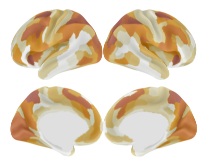

In [7]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from lstnn.plotting import get_cropped_img
plt.rcParams['svg.fonttype'] = 'none'


# gridspec inside gridspec
fig = plt.figure(figsize=(2.4, 2))

# rows
rows = gridspec.GridSpec(2, 1, figure=fig, hspace=0, wspace=0, height_ratios=[0.01, 0.495*2])

# create gridspec between brains and scatter plot
grid = gridspec.GridSpec(2, 2, figure=fig, hspace=0, wspace=0)

brain_grid = gridspec.GridSpec(2, 2, hspace=0, wspace=0)
b_count = 0
for view in ['lateral', 'medial']:
    for hemi in ['left', 'right']:

        # get image
        img = plt.imread(f"../figures/brain_plots/noise_ceiling_contoured_{hemi}_{view}.jpeg")
        img_cropped = get_cropped_img(img,
                                    x_start_buffer=0,
                                    x_finish_buffer=0,
                                    y_start_buffer=0,
                                    y_finish_buffer=0)

        # get ax
        ax = fig.add_subplot(brain_grid[b_count])
        ax.set_xticklabels([])
        ax.set_yticklabels([])
        ax.set_xticks([])
        ax.set_yticks([])
        ax.imshow(img_cropped, aspect='equal', rasterized=True)
        sns.despine(left=True, bottom=True, ax=ax)
        b_count = b_count+1

plt.savefig("../figures/noise_ceiling_brains.svg", dpi=1200)
plt.show()

# Plot results

In [8]:
def percentile_bars(plot_data, ax, col):
    x = 0
    for roi in plot_data.parcel.unique():
        y1 = plot_data.loc[(plot_data.parcel == roi) 
                        & (plot_data.permutation == "noise ceiling corr. bottom"),
                        "stat"].values[0]
        y2 = plot_data.loc[(plot_data.parcel == roi) 
                        & (plot_data.permutation == "noise ceiling corr. top"),
                        "stat"].values[0]
        ax.plot([x, x], [y1, y2], color=col, alpha=0.55, zorder=5, lw=2)
        x = x+1

In [ ]:


plot_data.head()

,stat,permutation,compare_method,model,parcel,it,pe,fmethod,cmethod,amethod,epoch,p_FDR,percentile,network
294,0.151437,False,corr,attn_out_avg,R V2,0.0,2dpe,crossnobis,corr,euclidean,4000.0,0.000000,1.0000,Visual2
309,0.121942,False,corr,attn_out_avg,R V3,0.0,2dpe,crossnobis,corr,euclidean,4000.0,0.000000,1.0000,Visual2
1239,0.107954,False,corr,attn_out_avg,R 8Av,0.0,2dpe,crossnobis,corr,euclidean,4000.0,0.000000,1.0000,Default
1389,0.127977,False,corr,attn_out_avg,R a47r,0.0,2dpe,crossnobis,corr,euclidean,4000.0,0.021157,0.9999,Frontoparietal
1704,0.102461,False,corr,attn_out_avg,R s6-8,0.0,2dpe,crossnobis,corr,euclidean,4000.0,0.021157,0.9999,Frontoparietal


/tmp/ipykernel_1089495/742930458.py:23: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
/tmp/ipykernel_1089495/742930458.py:25: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation=="noise ceiling corr."], x="parcel", y="stat",
/tmp/ipykernel_1089495/742930458.py:51: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
/tmp/ipykernel_1089495/742930458.py:53: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between point

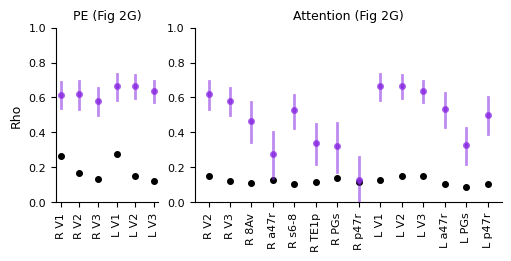

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.rcParams['svg.fonttype'] = 'none'
col2="blueviolet"
fig, axs = plt.subplot_mosaic("""
                              ABBB
                              """,
                              figsize=(5.0, 2.5),
                              constrained_layout=True)
ax = axs["A"]
model = "pe_avg"
model_label = "PE (Fig 2G)"

plot_data = data.loc[data.model == model]
for roi in plot_data.parcel.unique():
    df = noise_ceilings.loc[(noise_ceilings.parcel == roi)]
    plot_data = pd.concat([plot_data, df])
plot_data['parcel'] = plot_data['parcel'].str.removesuffix('_ROI')
plot_data['parcel'] = plot_data['parcel'].str.replace('R_', 'R ')
plot_data['parcel'] = plot_data['parcel'].str.replace('L_', 'L ')

sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
              join=False, color="k", markersize=3, ax=ax)
sns.pointplot(data=plot_data.loc[plot_data.permutation=="noise ceiling corr."], x="parcel", y="stat",
              join=False, color=col2, markersize=3, ax=ax, alpha=0.75)
percentile_bars(plot_data, ax, col2)


# plot properties
ax.set_ylim([0, 1])
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel("")
ax.set_title(model_label, loc='center', fontsize=9, ha="center")
sns.despine(ax=ax)
ax.set_ylabel("Rho", fontsize=9)

ax = axs["B"]
model = "attn_out_avg"
model_label = "Attention (Fig 2G)"

plot_data = data.loc[data.model == model]
for roi in plot_data.parcel.unique():
    df = noise_ceilings.loc[(noise_ceilings.parcel == roi)]
    plot_data = pd.concat([plot_data, df])
plot_data['parcel'] = plot_data['parcel'].str.removesuffix('_ROI')
plot_data['parcel'] = plot_data['parcel'].str.replace('R_', 'R ')
plot_data['parcel'] = plot_data['parcel'].str.replace('L_', 'L ')

sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
              join=False, color="k", markersize=3, ax=ax)
sns.pointplot(data=plot_data.loc[plot_data.permutation=="noise ceiling corr."], x="parcel", y="stat",
              join=False, color=col2, markersize=3, ax=ax, alpha=0.75, dodge=False)
percentile_bars(plot_data, ax, col2)

# plot properties
ax.set_ylim([0, 1])
ax.tick_params(axis='x', rotation=90)
ax.tick_params(axis='both', which='major', labelsize=8)
ax.set_xlabel("")
ax.set_title(model_label, loc='center', fontsize=9, ha="center")
sns.despine(ax=ax)
ax.set_ylabel("", fontsize=9)
plt.savefig("../figures/noise_ceiling_2G.svg", dpi=1200)
plt.show()

/tmp/ipykernel_1089495/3063656933.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
/tmp/ipykernel_1089495/3063656933.py:24: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation=="noise ceiling corr."], x="parcel", y="stat",
/tmp/ipykernel_1089495/3063656933.py:22: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between points with `linestyle='none'`.

  sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
/tmp/ipykernel_1089495/3063656933.py:24: UserWarning: 

The `join` parameter is deprecated and will be removed in v0.15.0. You can remove the line between p

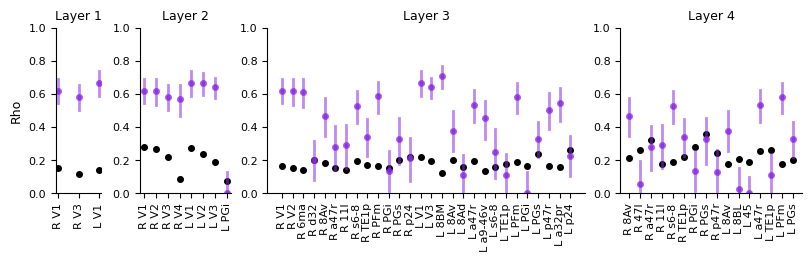

In [17]:
plt.rcParams['svg.fonttype'] = 'none'
col2="blueviolet"
fig, axs = plt.subplot_mosaic("""
                              ABBCCCCCCCDDDD
                              """,
                              figsize=(8.0, 2.5),
                              constrained_layout=True)

for layer, ax_label in zip([0, 1, 2 , 3], ["A", "B", "C", "D"]):
    ax = axs[ax_label]
    model = "mlp_layer"+str(layer)
    model_label = "Layer "+str(layer+1)

    plot_data = data.loc[data.model == model]
    for roi in plot_data.parcel.unique():
        df = noise_ceilings.loc[(noise_ceilings.parcel == roi)]
        plot_data = pd.concat([plot_data, df])
    plot_data['parcel'] = plot_data['parcel'].str.removesuffix('_ROI')
    plot_data['parcel'] = plot_data['parcel'].str.replace('R_', 'R ')
    plot_data['parcel'] = plot_data['parcel'].str.replace('L_', 'L ')

    sns.pointplot(data=plot_data.loc[plot_data.permutation==False], x="parcel", y="stat",
                join=False, color="k", markersize=3, ax=ax)
    sns.pointplot(data=plot_data.loc[plot_data.permutation=="noise ceiling corr."], x="parcel", y="stat",
                join=False, color=col2, markersize=3, ax=ax, alpha=0.75, dodge=False)
    percentile_bars(plot_data, ax, col2)

    # plot properties
    ax.set_ylim([0, 1])
    ax.tick_params(axis='x', rotation=90)
    ax.tick_params(axis='both', which='major', labelsize=8)
    ax.set_xlabel("")
    ax.set_title(model_label, loc='center', fontsize=9, ha="center")
    sns.despine(ax=ax)
    if layer == 0:
        ax.set_ylabel("Rho", fontsize=9)
    else:
        ax.set_ylabel("", fontsize=9)
plt.savefig("../figures/noise_ceiling_5.svg", dpi=1200)
plt.show()